## Imports:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("✅ Imports done")

✅ Imports done


##  Load data:

In [6]:
df = pd.read_csv('/kaggle/input/datasets/sharduldhekane/code-mixed-hinglish-hate-speech-detection-dataset/combined_hate_speech_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nNull Values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated(subset=['text']).sum()}")

Shape: (29550, 9)

Columns: ['text', 'hate_label', 'source', 'profanity_score', 'language', 'dataset_version', 'combined_date', 'text_length', 'word_count']

Data Types:
text               object
hate_label          int64
source             object
profanity_score     int64
language           object
dataset_version    object
combined_date      object
text_length         int64
word_count          int64
dtype: object

Null Values:
text               0
hate_label         0
source             0
profanity_score    0
language           0
dataset_version    0
combined_date      0
text_length        0
word_count         0
dtype: int64

Duplicate rows: 11


## Label distribution

LABEL DISTRIBUTION ANALYSIS

Counts:
  NOT (Non-hate): 15825 (53.6%)
  HOF (Hate/Offensive): 13725 (46.4%)

⚠️  Imbalance Ratio: 1.15x
(Above 3x = serious imbalance, needs handling)


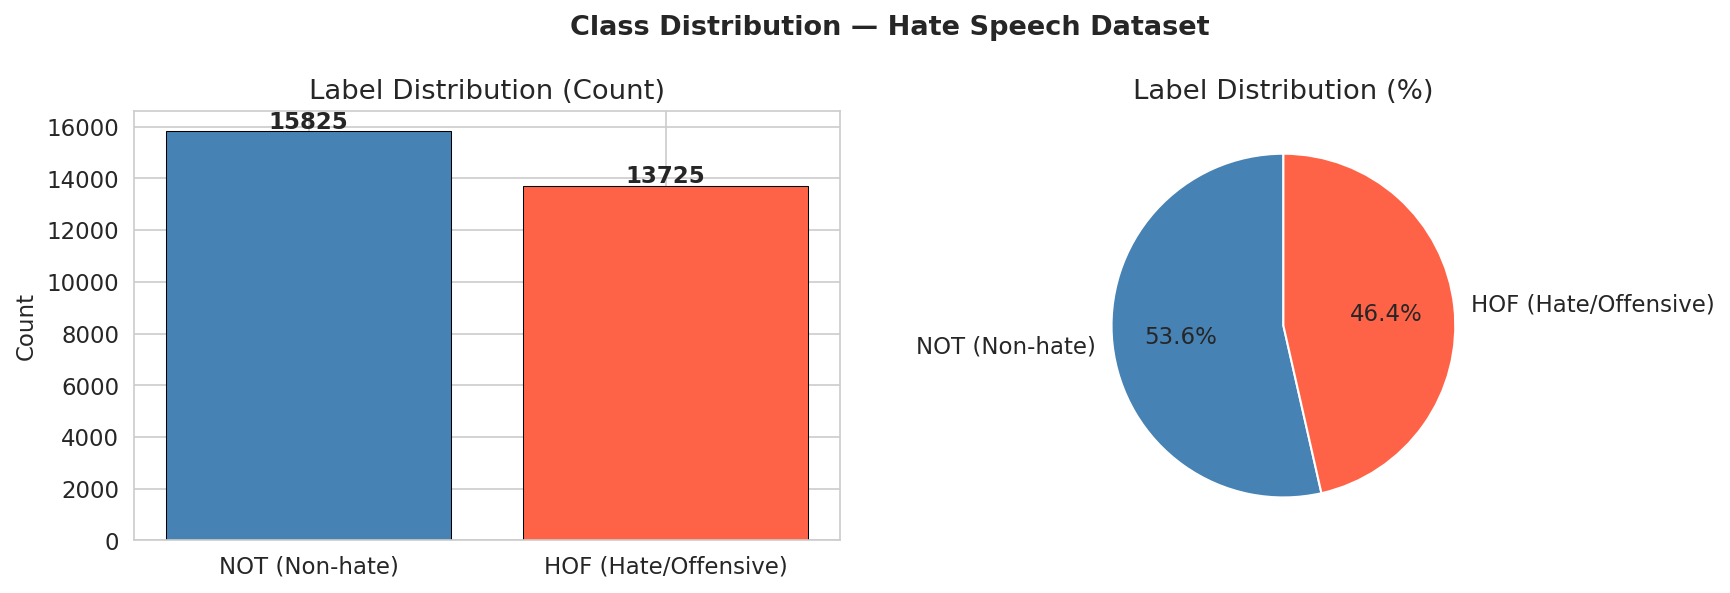

In [7]:
print("="*50)
print("LABEL DISTRIBUTION ANALYSIS")
print("="*50)

label_map = {0: 'NOT (Non-hate)', 1: 'HOF (Hate/Offensive)'}
df['label_name'] = df['hate_label'].map(label_map)

counts = df['hate_label'].value_counts()
pcts   = df['hate_label'].value_counts(normalize=True) * 100

print("\nCounts:")
for k, v in counts.items():
    print(f"  {label_map[k]}: {v} ({pcts[k]:.1f}%)")

# Imbalance ratio
ratio = counts.max() / counts.min()
print(f"\n⚠️  Imbalance Ratio: {ratio:.2f}x")
print("(Above 3x = serious imbalance, needs handling)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
axes[0].bar(
    [label_map[0], label_map[1]],
    [counts[0], counts[1]],
    color=['steelblue', 'tomato'],
    edgecolor='black', linewidth=0.5
)
axes[0].set_title('Label Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(
    [counts[0], counts[1]],
    labels=[label_map[0], label_map[1]],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Label Distribution (%)')

plt.suptitle('Class Distribution — Hate Speech Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Language distribution:

In [ ]:
print("="*50)
print("LANGUAGE DISTRIBUTION")
print("="*50)

lang_counts = df['language'].value_counts()
print(lang_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Language overall
lang_counts.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='black')
axes[0].set_title('Language Distribution (Overall)')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=45)

# Language vs Label (stacked)
lang_label = df.groupby(['language', 'label_name']).size().unstack(fill_value=0)
lang_label.plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[1].set_title('Language vs Label Distribution')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=45)
axes[1].legend(title='Label')

plt.tight_layout()
plt.savefig('language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##  Source distribution:

SOURCE DISTRIBUTION
source
english_dataset    15000
hindi_dataset       9767
hate_speech_tsv     4574
profanity_list       209
Name: count, dtype: int64


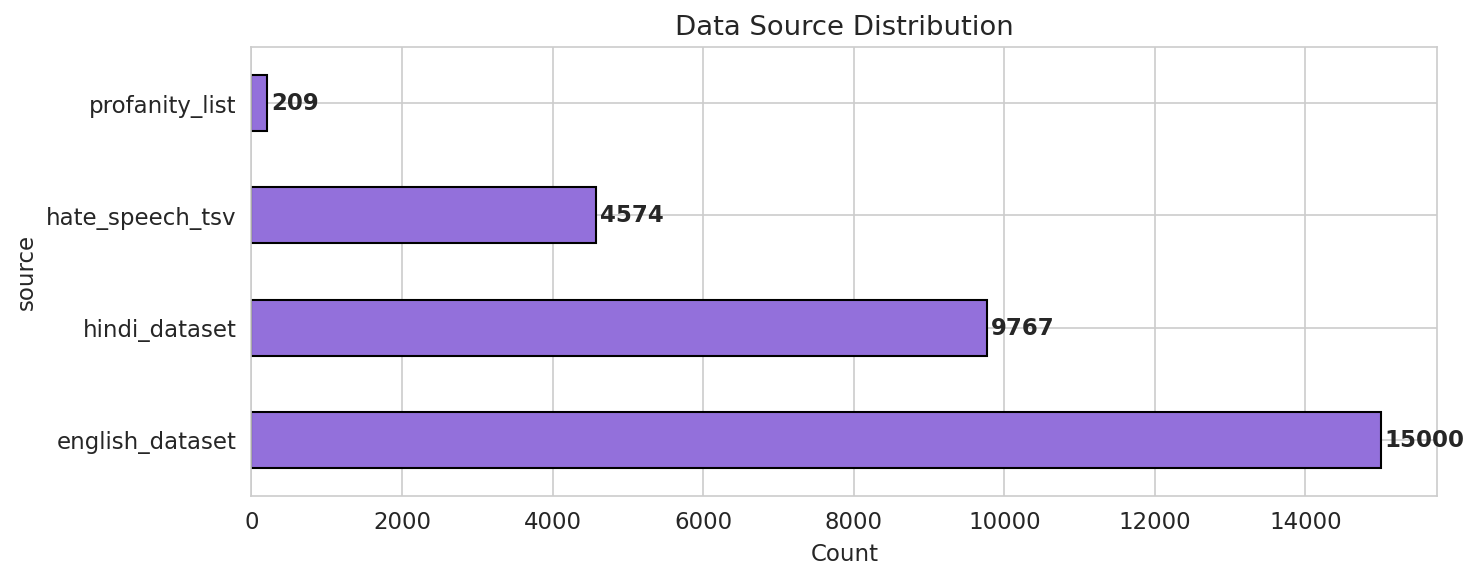

In [8]:
print("="*50)
print("SOURCE DISTRIBUTION")
print("="*50)

src_counts = df['source'].value_counts()
print(src_counts)

fig, ax = plt.subplots(figsize=(10, 4))
src_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Data Source Distribution')
ax.set_xlabel('Count')

for i, v in enumerate(src_counts.values):
    ax.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Text length analysis:

TEXT LENGTH ANALYSIS

Text Length by Label:
                     text_length                                         \
                           count   mean    std  min   25%    50%    75%   
label_name                                                                
HOF (Hate/Offensive)     13725.0  125.1  142.6  1.0  49.0   85.0  145.0   
NOT (Non-hate)           15825.0  172.5  220.2  2.0  57.0  102.0  191.0   

                             word_count                                     \
                         max      count  mean   std  min   25%   50%   75%   
label_name                                                                   
HOF (Hate/Offensive)  1896.0    13725.0  23.7  26.4  1.0  10.0  16.0  28.0   
NOT (Non-hate)        1926.0    15825.0  32.4  39.9  1.0  11.0  19.0  36.0   

                             
                        max  
label_name                   
HOF (Hate/Offensive)  295.0  
NOT (Non-hate)        300.0  


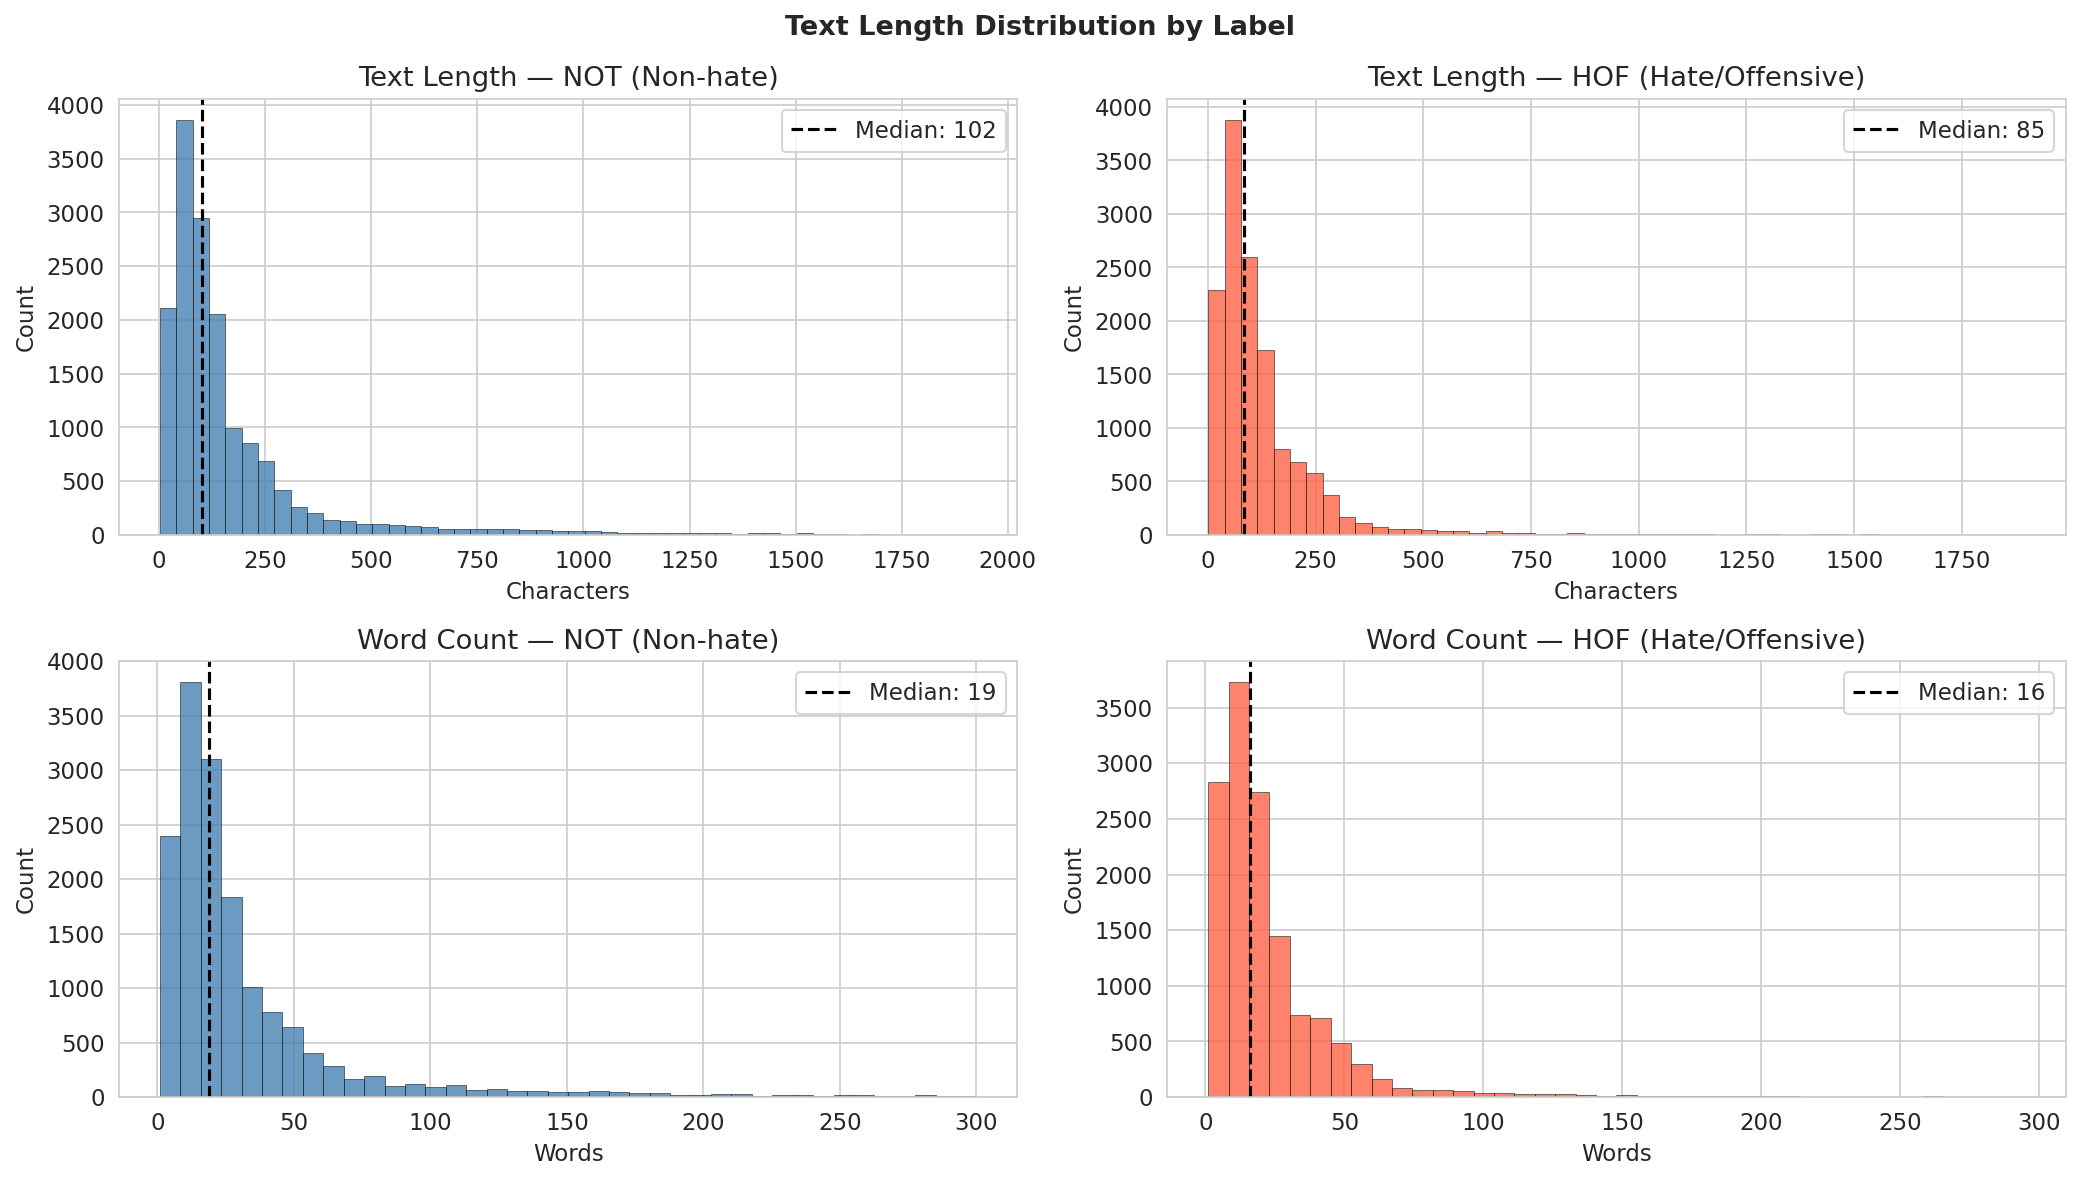

In [9]:
print("="*50)
print("TEXT LENGTH ANALYSIS")
print("="*50)

print("\nText Length by Label:")
print(df.groupby('label_name')[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (label, color) in enumerate([(0, 'steelblue'), (1, 'tomato')]):
    subset = df[df['hate_label'] == label]
    name = label_map[label]

    # Text length
    axes[0][idx].hist(subset['text_length'], bins=50, color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
    axes[0][idx].set_title(f'Text Length — {name}')
    axes[0][idx].set_xlabel('Characters')
    axes[0][idx].set_ylabel('Count')
    axes[0][idx].axvline(subset['text_length'].median(), color='black', linestyle='--', label=f'Median: {subset["text_length"].median():.0f}')
    axes[0][idx].legend()

    # Word count
    axes[1][idx].hist(subset['word_count'], bins=40, color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
    axes[1][idx].set_title(f'Word Count — {name}')
    axes[1][idx].set_xlabel('Words')
    axes[1][idx].set_ylabel('Count')
    axes[1][idx].axvline(subset['word_count'].median(), color='black', linestyle='--', label=f'Median: {subset["word_count"].median():.0f}')
    axes[1][idx].legend()

plt.suptitle('Text Length Distribution by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Profanity score analysis:

PROFANITY SCORE ANALYSIS
                        count   mean    std  min  25%  50%  75%   max
label_name                                                           
HOF (Hate/Offensive)  13725.0  0.085  0.766  0.0  0.0  0.0  0.0  10.0
NOT (Non-hate)        15825.0  0.000  0.000  0.0  0.0  0.0  0.0   0.0

T-test HOF vs NOT profanity scores:
  t-stat: 14.009, p-value: 0.0000
  ✅ Significant difference!


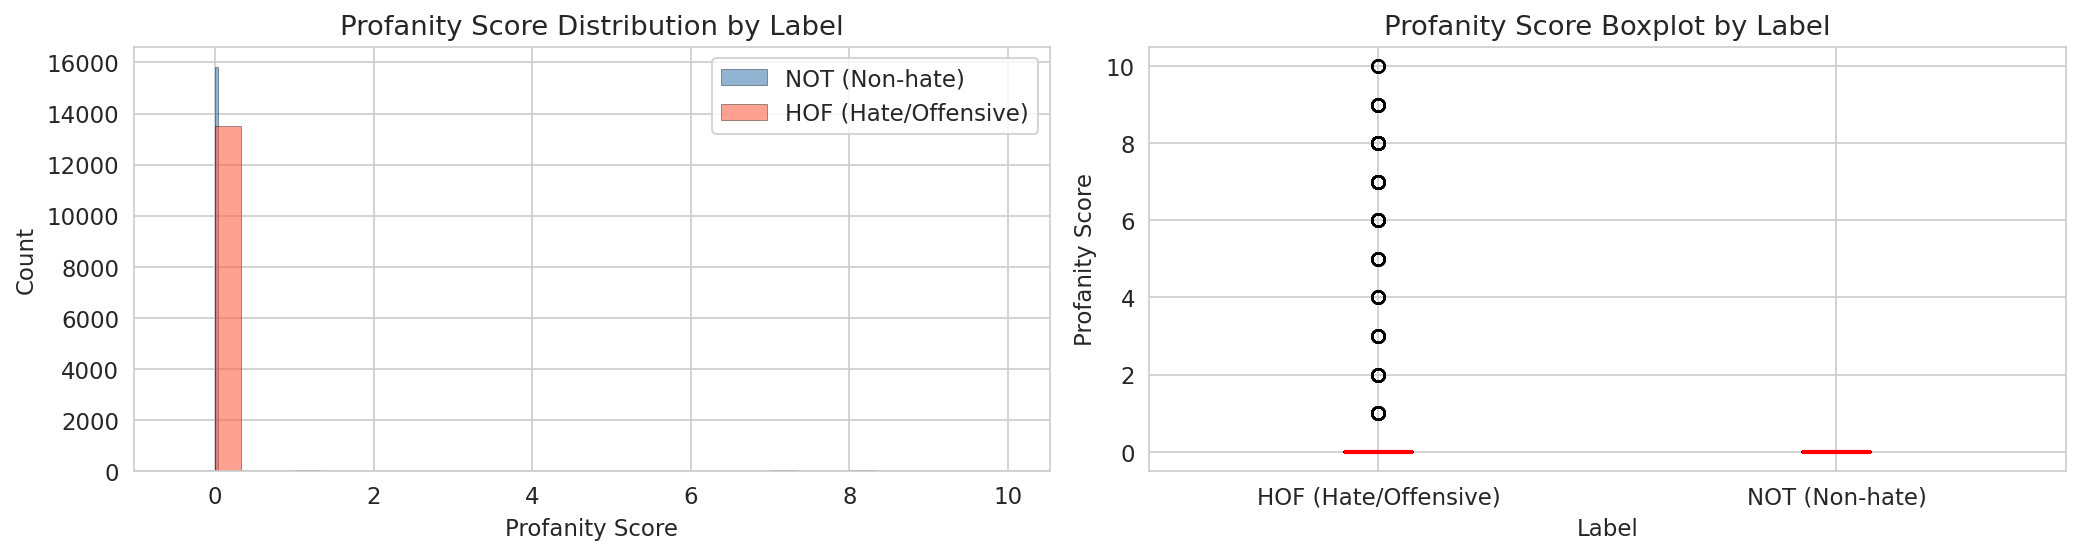

In [10]:
print("="*50)
print("PROFANITY SCORE ANALYSIS")
print("="*50)

print(df.groupby('label_name')['profanity_score'].describe().round(3))

# Is profanity score useful? Check correlation
from scipy import stats
hof_scores = df[df['hate_label'] == 1]['profanity_score']
not_scores = df[df['hate_label'] == 0]['profanity_score']

t_stat, p_val = stats.ttest_ind(hof_scores, not_scores)
print(f"\nT-test HOF vs NOT profanity scores:")
print(f"  t-stat: {t_stat:.3f}, p-value: {p_val:.4f}")
print(f"  {'✅ Significant difference!' if p_val < 0.05 else '❌ No significant difference'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = df[df['hate_label'] == label]
    axes[0].hist(subset['profanity_score'], bins=30, alpha=0.6,
                 color=color, label=label_map[label], edgecolor='black', linewidth=0.3)
axes[0].set_title('Profanity Score Distribution by Label')
axes[0].set_xlabel('Profanity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
df.boxplot(column='profanity_score', by='label_name', ax=axes[1],
           boxprops=dict(color='black'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Profanity Score Boxplot by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Profanity Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig('profanity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Sample texts

In [11]:
print("="*50)
print("SAMPLE HATE/OFFENSIVE TEXTS (HOF)")
print("="*50)
hof = df[df['hate_label'] == 1]['text'].sample(5, random_state=42)
for i, t in enumerate(hof, 1):
    print(f"\n{i}. {t}")

print("\n" + "="*50)
print("SAMPLE NON-HATE TEXTS (NOT)")
print("="*50)
not_ = df[df['hate_label'] == 0]['text'].sample(5, random_state=42)
for i, t in enumerate(not_, 1):
    print(f"\n{i}. {t}")

SAMPLE HATE/OFFENSIVE TEXTS (HOF)

1. अंग्रेज़ों का जीवन किसी के लिए भी महत्वपूर्ण नहीं होना चाहिए

2. if nothing irks me more than when bitches end like it with playing a rather good guy and then someone complain about you getting hurt by being a douche mouth bag wakeupyouwhore

3. We hate judi bola.  https://twitter.com/aru5l1ar/status/818510370188890112 …

4. people are treated backwards

5. 100 Dino mai Bohat vikash kiya UP ny pura hindustan dekh raha hy rape murder etc Yahi hy vikas

SAMPLE NON-HATE TEXTS (NOT)

1. जनवरी से सभी कार्डधारकों को घर पर राशन उपलब्ध करायेगी केजरीवाल सरकार।
 

2. Kisi producer ne isko agar show diya to unki bohot bari galti hogi, bcoz isne logo ka itna nafrat gain kiya hai ki TRP zero ho jayega uss show ka. @i_shilpa_shinde @Im_ShilpaShinde @Shilpa_Shinde_ @shilpa_shindey

3. महिला के पति ने उसे पिछले  महीने से उसी के घर में जंजीरों से बांधकर रखा था पीड़ित महिला का पति उसके साथ मारपीट करता था और टॉर्चर करता था

 


4. इन मुसलमानों की तरह कोई और गदा नहीं ह

## Save clean version + summary:

In [12]:
print("="*50)
print("CLEANING & SAVING")
print("="*50)

# Keep only columns we need for modeling
df_clean = df[['text', 'hate_label', 'profanity_score', 'language', 'text_length', 'word_count']].copy()

# Rename for clarity
df_clean = df_clean.rename(columns={'hate_label': 'label'})

# Remove nulls
df_clean = df_clean.dropna(subset=['text', 'label'])

# Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['text'])
after = len(df_clean)
print(f"Removed {before - after} duplicate texts")

# Remove empty/too short texts
df_clean = df_clean[df_clean['text'].str.strip().str.len() > 5]

# Final stats
print(f"\n✅ Final clean dataset: {df_clean.shape}")
print(f"\nLabel distribution:")
print(df_clean['label'].value_counts())
print(f"\nImbalance ratio: {df_clean['label'].value_counts().max() / df_clean['label'].value_counts().min():.2f}x")

# Save
df_clean.to_csv('/kaggle/working/hasoc_clean.csv', index=False)
print("\n✅ Saved → /kaggle/working/hasoc_clean.csv")

# ── Summary card ──────────────────────────────────────────
print("\n" + "="*50)
print("📊 EDA SUMMARY — NOTE THESE DOWN")
print("="*50)
print(f"Total samples:      {len(df_clean)}")
print(f"NOT (label=0):      {(df_clean['label']==0).sum()}")
print(f"HOF (label=1):      {(df_clean['label']==1).sum()}")
print(f"Imbalance ratio:    {df_clean['label'].value_counts().max() / df_clean['label'].value_counts().min():.2f}x")
print(f"Avg text length:    {df_clean['text_length'].mean():.1f} chars")
print(f"Avg word count:     {df_clean['word_count'].mean():.1f} words")
print(f"Languages present:  {df_clean['language'].nunique()}")
print(f"Max text length:    {df_clean['text_length'].max()} chars")

CLEANING & SAVING
Removed 11 duplicate texts

✅ Final clean dataset: (29440, 6)

Label distribution:
label
0    15807
1    13633
Name: count, dtype: int64

Imbalance ratio: 1.16x

✅ Saved → /kaggle/working/hasoc_clean.csv

📊 EDA SUMMARY — NOTE THESE DOWN
Total samples:      29440
NOT (label=0):      15807
HOF (label=1):      13633
Imbalance ratio:    1.16x
Avg text length:    151.0 chars
Avg word count:     28.5 words
Languages present:  3
Max text length:    1926 chars
